<a href="https://colab.research.google.com/github/sovestinet27/MIPT_SQL/blob/main/EDA_%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%A5%D0%B0%D0%BA%D0%B0%D1%82%D0%BE%D0%BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df_incidents = pd.read_csv('incidents_2000.csv', sep=';')
print(df_incidents.head())
print("\n" + "-" * 30 + "\n")

df_fstek = pd.read_csv('Файл с сайта ФСТЭК.csv', sep=';')
df_fstek.columns = df_fstek.iloc[0]
df_fstek = df_fstek[1:]
df_fstek = df_fstek.reset_index(drop=True)
print(df_fstek.head())

grouping_cols = [
    'Тип предприятия',
    'Код предприятия',
    'Код реализованной угрозы',
    'Регион размещения предприятия'
]
df_incidents['Количество хостов'] = df_incidents.groupby(grouping_cols)['Количество хостов'].transform('first')
print(df_incidents.head())

  Тип предприятия  Код предприятия  Количество хостов  \
0             НКО             1825                251   
1           химия             8936                378   
2           отели             8280               1432   
3    фармацевтика             4558               1857   
4      энергетика             3528               1763   

   Код реализованной угрозы  Успех Регион размещения предприятия  \
0                       190      1              Республика Марий   
1                       152      1             Республика Адыгея   
2                         7      0                   Севастополь   
3                       223      0            Смоленская область   
4                        87      0         Архангельская область   

  Региональное время  
0   02.04.2024 07:47  
1   03.03.2023 05:13  
2   09.05.2025 10:28  
3   15.05.2025 13:17  
4   17.02.2025 06:22  

------------------------------

0 Идентификатор УБИ                                   Наименование УБИ  \
0  

### 1. Подготовка и очистка данных

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df_incidents['Региональное время'] = pd.to_datetime(df_incidents['Региональное время'], format='%d.%m.%Y %H:%M', errors='coerce')

df_incidents['Год'] = df_incidents['Региональное время'].dt.year
df_incidents['Месяц'] = df_incidents['Региональное время'].dt.month
df_incidents['День недели'] = df_incidents['Региональное время'].dt.dayofweek # 0 - Пн, 6 - Вс
df_incidents['Час'] = df_incidents['Региональное время'].dt.hour
df_incidents['Выходной'] = df_incidents['День недели'].apply(lambda x: 1 if x >= 5 else 0)

df_fstek_renamed = df_fstek.rename(columns={'Идентификатор УБИ': 'Код реализованной угрозы'})
df_fstek_renamed['Код реализованной угрозы'] = pd.to_numeric(df_fstek_renamed['Код реализованной угрозы'], errors='coerce')

df_merged = pd.merge(
    df_incidents,
    df_fstek_renamed[['Код реализованной угрозы', 'Объект воздействия', 'Нарушение конфиденциальности', 'Нарушение целостности', 'Нарушение доступности']],
    on='Код реализованной угрозы',
    how='left'
)

print(f"Размер объединенного датасета: {df_merged.shape}")
display(df_merged.head())

Размер объединенного датасета: (1948, 16)


,Тип предприятия,Код предприятия,Количество хостов,Код реализованной угрозы,Успех,Регион размещения предприятия,Региональное время,Год,Месяц,День недели,Час,Выходной,Объект воздействия,Нарушение конфиденциальности,Нарушение целостности,Нарушение доступности
0,НКО,1825,251,190,1,Республика Марий,2024-04-02 07:47:00,2024,4,1,7,0,Сетевое программное обеспечение,1,1,1
1,химия,8936,378,152,1,Республика Адыгея,2023-03-03 05:13:00,2023,3,4,5,0,"Системное программное обеспечение, микропрогра...",1,1,1
2,отели,8280,1432,7,0,Севастополь,2025-05-09 10:28:00,2025,5,4,10,0,"Информационная система, виртуальная машина, се...",1,1,0
3,фармацевтика,4558,1857,223,0,Смоленская область,2025-05-15 13:17:00,2025,5,3,13,0,Docker-контейнер,1,1,1
4,энергетика,3528,1763,87,0,Архангельская область,2025-02-17 06:22:00,2025,2,0,6,0,"Аппаратное обеспечение, микропрограммное обесп...",1,1,1


### 2. Анализ успешности атак по отраслям

/tmp/ipykernel_36732/1624378020.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=industry_success.head(15), x='Доля успеха', y='Тип предприятия', palette='Reds_r')


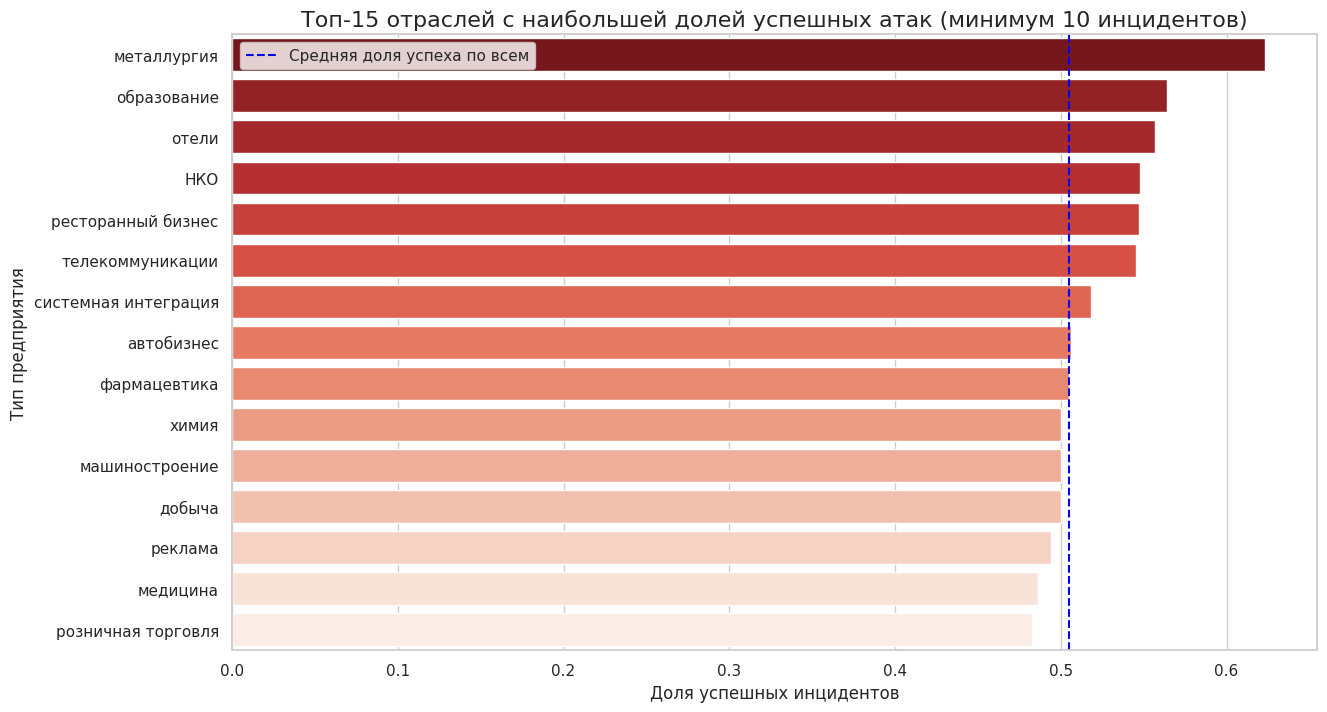

,Тип предприятия,Всего атак,Доля успеха
10,металлургия,77,0.623377
11,образование,94,0.563830
12,отели,88,0.556818
0,НКО,115,0.547826
14,ресторанный бизнес,95,0.547368
17,телекоммуникации,88,0.545455
16,системная интеграция,83,0.518072
1,автобизнес,85,0.505882
18,фармацевтика,105,0.504762
19,химия,100,0.500000


In [ ]:
industry_success = df_merged.groupby('Тип предприятия')['Успех'].agg(['count', 'mean']).reset_index()
industry_success = industry_success.rename(columns={'count': 'Всего атак', 'mean': 'Доля успеха'})
industry_success = industry_success[industry_success['Всего атак'] > 10]
industry_success = industry_success.sort_values('Доля успеха', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(data=industry_success.head(15), x='Доля успеха', y='Тип предприятия', palette='Reds_r')
plt.title('Топ-15 отраслей с наибольшей долей успешных атак (минимум 10 инцидентов)', fontsize=16)
plt.xlabel('Доля успешных инцидентов', fontsize=12)
plt.ylabel('Тип предприятия', fontsize=12)
plt.axvline(df_merged['Успех'].mean(), color='blue', linestyle='--', label='Средняя доля успеха по всем')
plt.legend()
plt.show()

display(industry_success.head(10))

### 3. Временной анализ

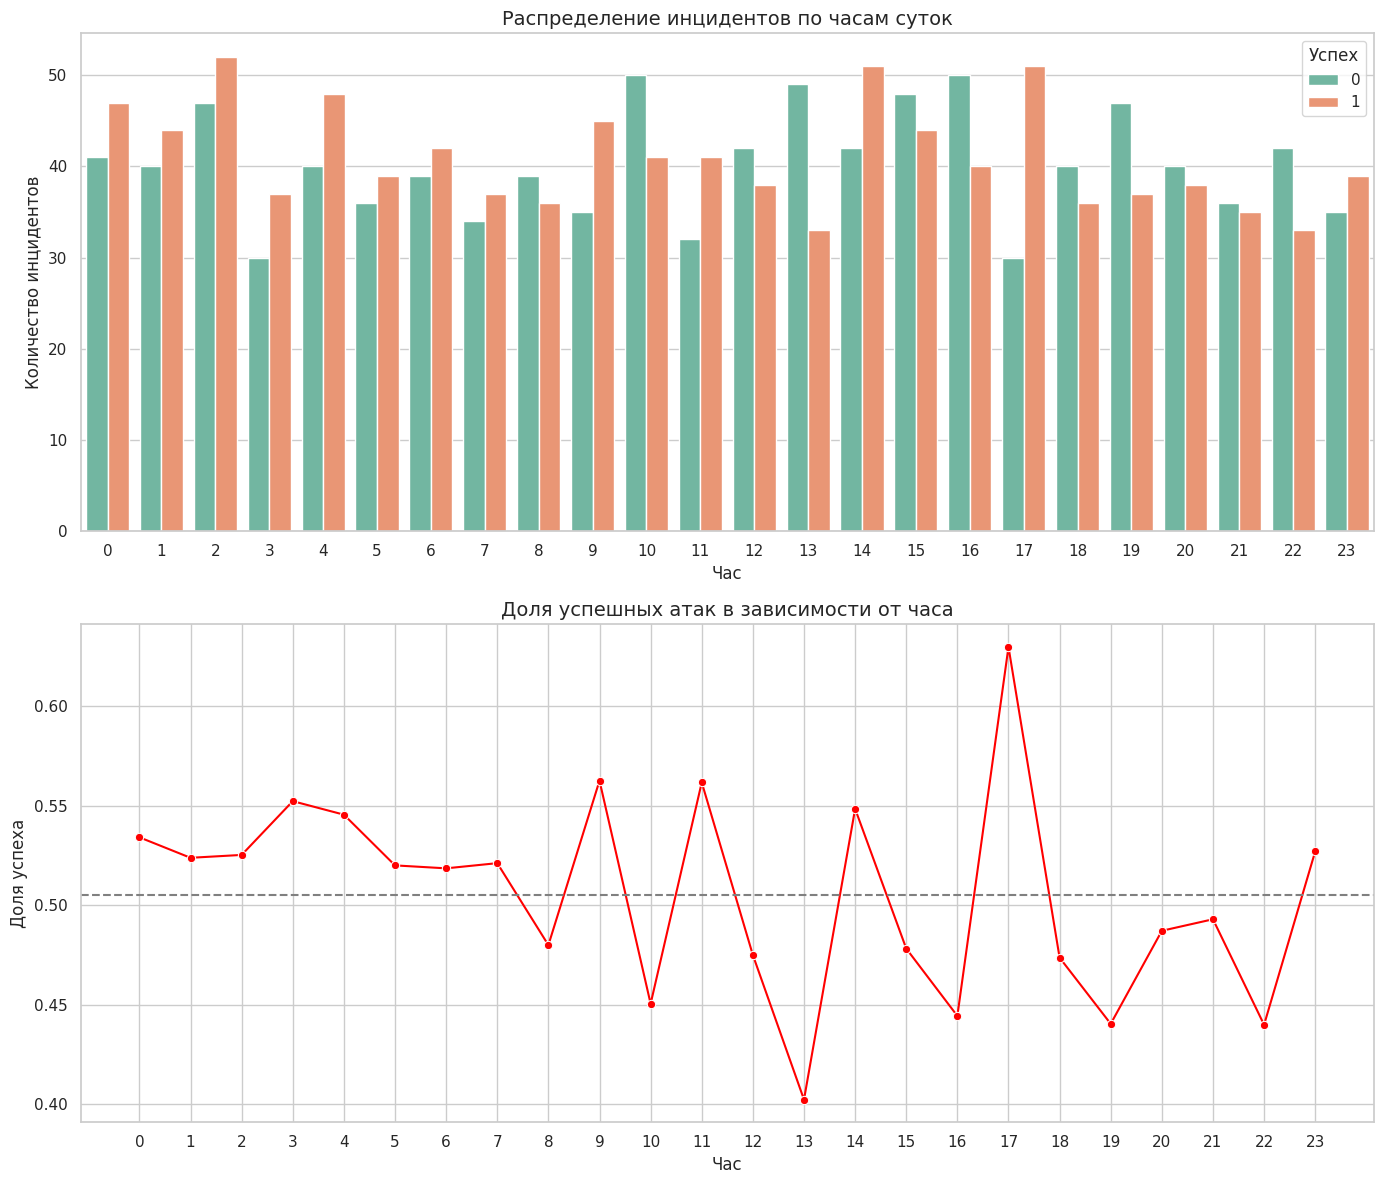

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.countplot(data=df_merged, x='Час', hue='Успех', ax=axes[0], palette='Set2')
axes[0].set_title('Распределение инцидентов по часам суток', fontsize=14)
axes[0].set_ylabel('Количество инцидентов')

hourly_success = df_merged.groupby('Час')['Успех'].mean().reset_index()
sns.lineplot(data=hourly_success, x='Час', y='Успех', marker='o', color='red', ax=axes[1])
axes[1].set_title('Доля успешных атак в зависимости от часа', fontsize=14)
axes[1].set_ylabel('Доля успеха')
axes[1].axhline(df_merged['Успех'].mean(), color='gray', linestyle='--')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

### 4. Анализ объектов воздействия
Поскольку 'Объект воздействия' содержит длинные текстовые описания, мы категоризируем их.

/tmp/ipykernel_36732/463362986.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=target_stats, y='Категория объекта', x='mean', palette='magma')


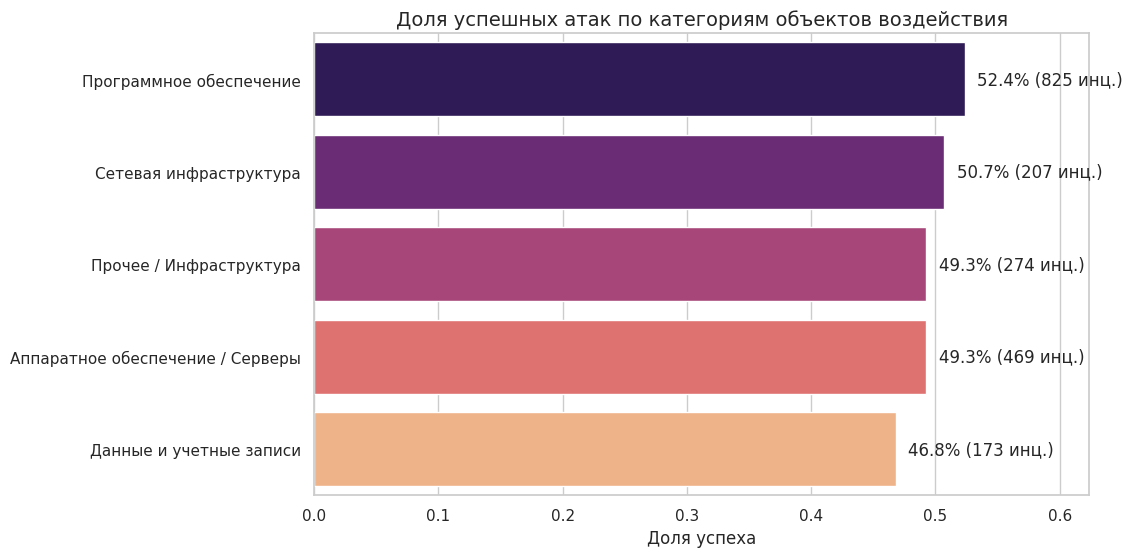

In [ ]:
def categorize_target(text):
    text = str(text).lower()
    if any(word in text for word in ['сеть', 'трафик', 'коммутатор', 'маршрутизатор']):
        return 'Сетевая инфраструктура'
    elif any(word in text for word in ['сервер', 'аппаратн', 'bios', 'uefi']):
        return 'Аппаратное обеспечение / Серверы'
    elif any(word in text for word in ['по', 'приложен', 'программ', 'ос ']):
        return 'Программное обеспечение'
    elif any(word in text for word in ['данные', 'информац', 'учетн', 'парол']):
        return 'Данные и учетные записи'
    else:
        return 'Прочее / Инфраструктура'

df_merged['Категория объекта'] = df_merged['Объект воздействия'].apply(categorize_target)

target_stats = df_merged.groupby('Категория объекта')['Успех'].agg(['count', 'mean']).reset_index()
target_stats = target_stats.sort_values('mean', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=target_stats, y='Категория объекта', x='mean', palette='magma')
plt.title('Доля успешных атак по категориям объектов воздействия', fontsize=14)
plt.xlabel('Доля успеха')
plt.ylabel('')
for i, v in enumerate(target_stats['mean']):
    plt.text(v + 0.01, i, f"{v:.1%} ({target_stats.iloc[i]['count']} инц.)", va='center')
plt.xlim(0, max(target_stats['mean']) + 0.1)
plt.show()

### 5. Влияние размера предприятия (Количество хостов) на успешность

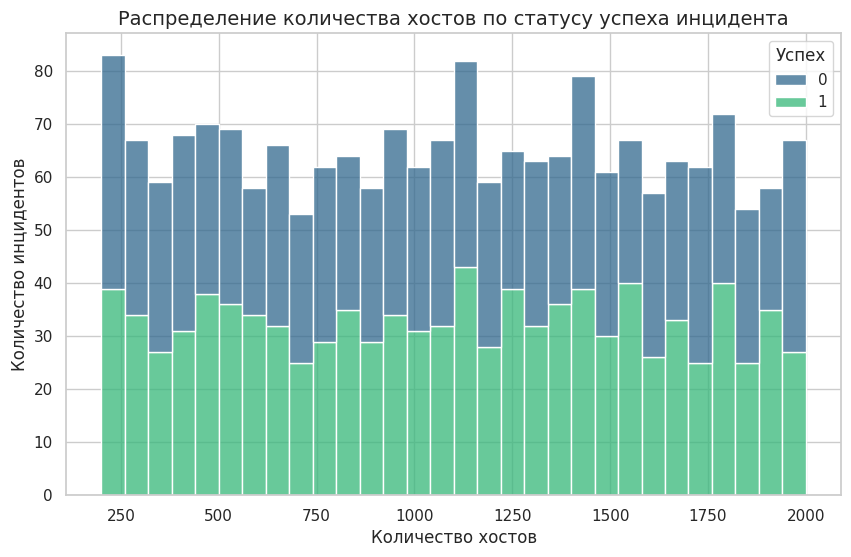

,Размер инфраструктуры,Успех
0,Малая,0.497951
1,Средняя,0.497942
2,Крупная,0.523614
3,Очень крупная,0.501027


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_merged, x='Количество хостов', hue='Успех', multiple='stack', bins=30, palette='viridis')
plt.title('Распределение количества хостов по статусу успеха инцидента', fontsize=14)
plt.xlabel('Количество хостов', fontsize=12)
plt.ylabel('Количество инцидентов', fontsize=12)
plt.show()

df_merged['Размер инфраструктуры'] = pd.qcut(df_merged['Количество хостов'], q=4, labels=['Малая', 'Средняя', 'Крупная', 'Очень крупная'])
host_success = df_merged.groupby('Размер инфраструктуры', observed=False)['Успех'].mean().reset_index()

display(host_success)

### Итоговые выводы и найденные закономерности

1. **Отраслевая специфика (Тип предприятия):**
   - Наибольшая доля успешных атак наблюдается в сферах **металлургии (62.3%)**, **образования (56.3%)** и **отелей (55.6%)**.

2. **Временные паттерны:**
   - **Часы пиковой активности:** Наибольшее количество инцидентов фиксируется в рабочее время (около 10:00 и 14:00-16:00), а также наблюдается аномальный всплеск ночью (около 02:00).
   - **Успешность по времени:** Самая высокая доля успешных атак приходится на **17:00 (около 63%)** — возможно, это связано с концом рабочего дня, когда бдительность сотрудников снижается или когда IT начинает уходить домой.

3. **Объекты воздействия:**
   - Чаще всего объектами воздействия становятся **Программное обеспечение** (825 инцидентов) и **Аппаратное обеспечение/Серверы** (469 инцидентов).
   - При этом самая высокая доля успеха наблюдается при атаках на ПО и сетевую инфраструктуру соответственно.

### 6. Взаимосвязь времени суток и объекта воздействия


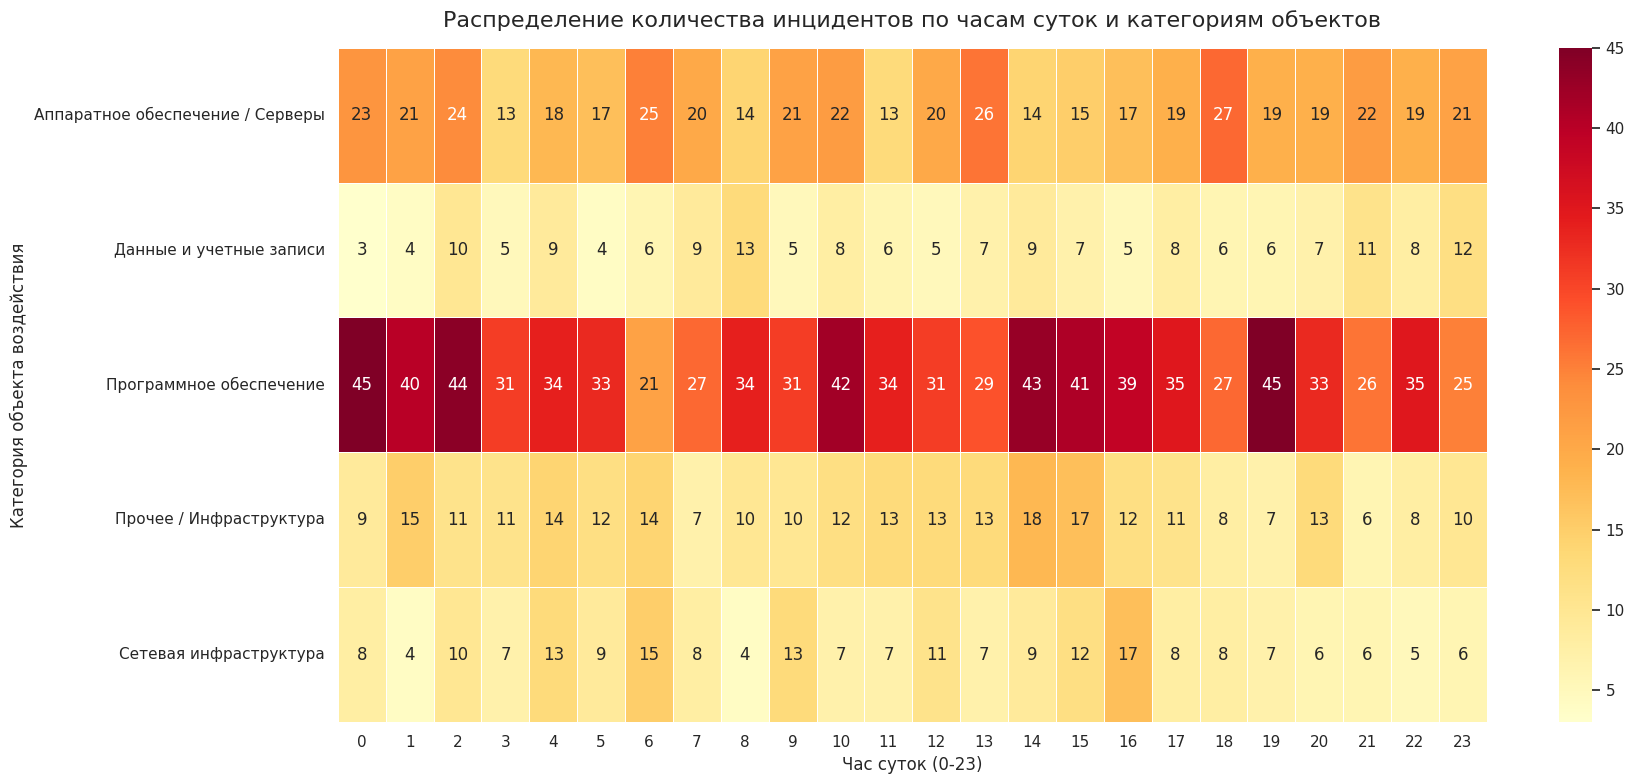

In [ ]:
heatmap_data = pd.crosstab(df_merged['Категория объекта'], df_merged['Час'])

plt.figure(figsize=(18, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5)
plt.title('Распределение количества инцидентов по часам суток и категориям объектов', fontsize=16, pad=15)
plt.xlabel('Час суток (0-23)', fontsize=12)
plt.ylabel('Категория объекта воздействия', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Выводы по взаимосвязи времени суток и объектов воздействия:**

1. **Отсутствие строгой привязки ко времени:** Злоумышленники не меняют тактику в зависимости от времени суток. Нет такого паттерна, при котором, например, сетевая инфраструктура атакуется строго ночью, а данные — днем. Атаки распределены по времени относительно равномерно.
2. **Доминирование Программного обеспечения:** На протяжении всех 24 часов категория «Программное обеспечение» остается абсолютным лидером по количеству инцидентов. Эта полоса на графике самая яркая в любой час.

### 7. Анализ последствий: Триада ИБ

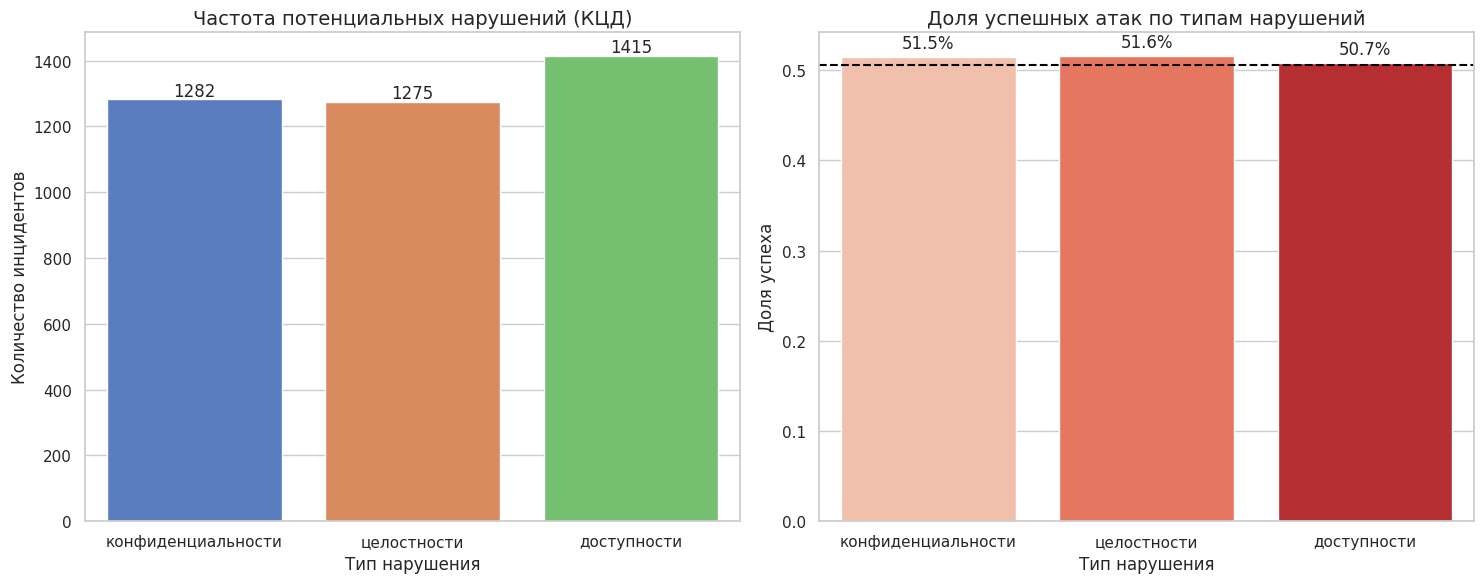

In [ ]:
cia_cols = ['Нарушение конфиденциальности', 'Нарушение целостности', 'Нарушение доступности']

for col in cia_cols:
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce').fillna(0).astype(int)

cia_stats = []
for col in cia_cols:
    subset = df_merged[df_merged[col] == 1]
    success_rate = subset['Успех'].mean()
    count = len(subset)
    cia_stats.append({'Тип нарушения': col.replace('Нарушение ', ''), 'Всего инцидентов': count, 'Доля успеха': success_rate})

cia_df = pd.DataFrame(cia_stats)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=cia_df, x='Тип нарушения', y='Всего инцидентов', hue='Тип нарушения', palette='muted', ax=axes[0], legend=False)
axes[0].set_title('Частота потенциальных нарушений (КЦД)', fontsize=14)
axes[0].set_ylabel('Количество инцидентов')
for i, v in enumerate(cia_df['Всего инцидентов']):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=12)

sns.barplot(data=cia_df, x='Тип нарушения', y='Доля успеха', hue='Тип нарушения', palette='Reds', ax=axes[1], legend=False)
axes[1].set_title('Доля успешных атак по типам нарушений', fontsize=14)
axes[1].axhline(df_merged['Успех'].mean(), color='black', linestyle='--', label='Средний успех')
axes[1].set_ylabel('Доля успеха')
for i, v in enumerate(cia_df['Доля успеха']):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha='center', fontsize=12)

plt.tight_layout()
plt.show()

### 8. Топ-10 конкретных угроз (Детализация по справочнику ФСТЭК)

In [ ]:
top_threats = df_merged.groupby('Код реализованной угрозы')['Успех'].agg(['count', 'mean']).reset_index()
top_threats = top_threats.sort_values('count', ascending=False).head(10)
top_threats = top_threats.rename(columns={'count': 'Количество инцидентов', 'mean': 'Доля успеха'})

top_threats_detailed = pd.merge(
    top_threats,
    df_fstek_renamed[['Код реализованной угрозы', 'Наименование УБИ']],
    on='Код реализованной угрозы',
    how='left'
)

top_threats_detailed['Наименование УБИ (кратко)'] = top_threats_detailed['Наименование УБИ'].apply(lambda x: str(x)[:80] + '...' if len(str(x)) > 80 else x)

display(top_threats_detailed[['Код реализованной угрозы', 'Количество инцидентов', 'Доля успеха', 'Наименование УБИ (кратко)']])

,Код реализованной угрозы,Количество инцидентов,Доля успеха,Наименование УБИ (кратко)
0,191,17,0.529412,Угроза внедрения вредоносного кода в дистрибут...
1,67,16,0.625000,Угроза неправомерного ознакомления с защищаемо...
2,41,16,0.625000,Угроза межсайтового скриптинга
3,26,15,0.533333,Угроза искажения XML-схемы
4,18,15,0.333333,Угроза загрузки нештатной операционной системы
5,73,15,0.666667,Угроза несанкционированного доступа к активном...
6,44,14,0.428571,Угроза нарушения изоляции пользовательских дан...
7,39,14,0.571429,"Угроза исчерпания запаса ключей, необходимых д..."
8,40,14,0.357143,Угроза конфликта юрисдикций различных стран
9,16,14,0.500000,Угроза доступа к локальным файлам сервера при ...


### Выводы по природе угроз

1. **Специфика Топ-10 угроз:**
   - Наиболее частой угрозой является **внедрение вредоносного кода** (52.9% успеха).
   - В топе также присутствуют веб-уязвимости: **межсайтовый скриптинг (XSS)** с высокой долей успеха в **62.5%**.
   - Выделяется угроза **несанкционированного доступа к активному сетевому оборудованию**, которая достигает максимальной успешности среди лидеров — **66.7%**.
   - Эти данные еще раз подчеркивают, что главными "воротами" для злоумышленников остаются уязвимости в программном обеспечении и конфигурациях сетевых устройств, что отлично коррелирует с нашими предыдущими выводами по объектам воздействия.